In [14]:
import os

# Delete the old corrupted file
if os.path.exists('drinking-waste-classification.zip'):
    !rm drinking-waste-classification.zip

# Re-download
!kaggle datasets download -d arkadiyhacks/drinking-waste-classification

# Check file size to confirm download
size = os.path.getsize('drinking-waste-classification.zip') / (1024*1024)
print(f"Download complete. File size: {size:.2f} MB")

Dataset URL: https://www.kaggle.com/datasets/arkadiyhacks/drinking-waste-classification
License(s): CC0-1.0
 99% 1.48G/1.50G [00:13<00:00, 231MB/s]
100% 1.50G/1.50G [00:13<00:00, 121MB/s]
Download complete. File size: 1531.19 MB


In [15]:
# Install 7zip if not available
!apt-get install p7zip-full -y

# Force extract to waste_data
!mkdir -p waste_data
!7z x drinking-waste-classification.zip -o./waste_data -y

# Verify if the folder was created
if os.path.exists('./waste_data'):
    print("Extraction successful!")
else:
    print("Extraction still failed. Trying Python's internal library...")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs AMD EPYC 7B12 (830F10),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 1605572649 bytes (1532 MiB)

Extracting archive: drinking-waste-classification.zip
 28% 4096 Open              --
Path = drinking-waste-classification.zip
Type = zip
Physical Size = 1605572649

  0%      0% 70 - Images_of_Waste/YOLO_imgs/AluCan1,035.jpg                                                     0% 149 - Images_of_Waste/YOLO_imgs/AluCan110.txt

In [16]:
import os

# Walk through the folders to find where the images actually are
for root, dirs, files in os.walk('./waste_data'):
    if 'rawimgs' in dirs:
        DATA_PATH = os.path.join(root, 'rawimgs')
        print(f"FOUND DATA AT: {DATA_PATH}")
        print("Categories:", os.listdir(DATA_PATH))
        break

FOUND DATA AT: ./waste_data/Images_of_Waste/rawimgs
Categories: ['HDPEM', 'AluCan', 'Glass', 'PET']


In [19]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# 1. Load Raw Training Set
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

# 2. Load Raw Validation Set
raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

# 3. Save Class Info (Crucial step!)
class_names = raw_train_ds.class_names
num_classes = len(class_names)
print(f"Categories found: {class_names}")

# 4. Apply MobileNetV2 Preprocessing to both
# This scales pixels to [-1, 1] as required by the model
train_ds = raw_train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = raw_val_ds.map(lambda x, y: (preprocess_input(x), y))

# 5. Optimize for Performance
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

Found 4820 files belonging to 4 classes.
Using 3856 files for training.
Found 4820 files belonging to 4 classes.
Using 964 files for validation.
Categories found: ['AluCan', 'Glass', 'HDPEM', 'PET']


In [20]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomBrightness(0.1),
])

# To apply it:
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

In [25]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# Load base model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

# Build final architecture
model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

# Training both sets
history = model.fit(
    train_ds,
    validation_data=val_ds, # The validation set you requested
    epochs=20,
    callbacks=[reduce_lr]
)

Epoch 1/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.2711 - loss: 1.5605 - val_accuracy: 0.3683 - val_loss: 1.3442 - learning_rate: 0.0010
Epoch 2/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.3064 - loss: 1.4399 - val_accuracy: 0.5913 - val_loss: 1.0102 - learning_rate: 0.0010
Epoch 3/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.3313 - loss: 1.4010 - val_accuracy: 0.6753 - val_loss: 0.8346 - learning_rate: 0.0010
Epoch 4/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.3607 - loss: 1.3425 - val_accuracy: 0.6981 - val_loss: 0.7702 - learning_rate: 0.0010
Epoch 5/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.3356 - loss: 1.3648 - val_accuracy: 0.7396 - val_loss: 0.6951 - learning_rate: 0.0010
Epoch 6/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.3536 - loss: 1.3347 - val_accuracy: 0.7490 - val_loss: 0.6741 - learning_rate: 0.0010
Epoch 7/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.3402 - loss: 1.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


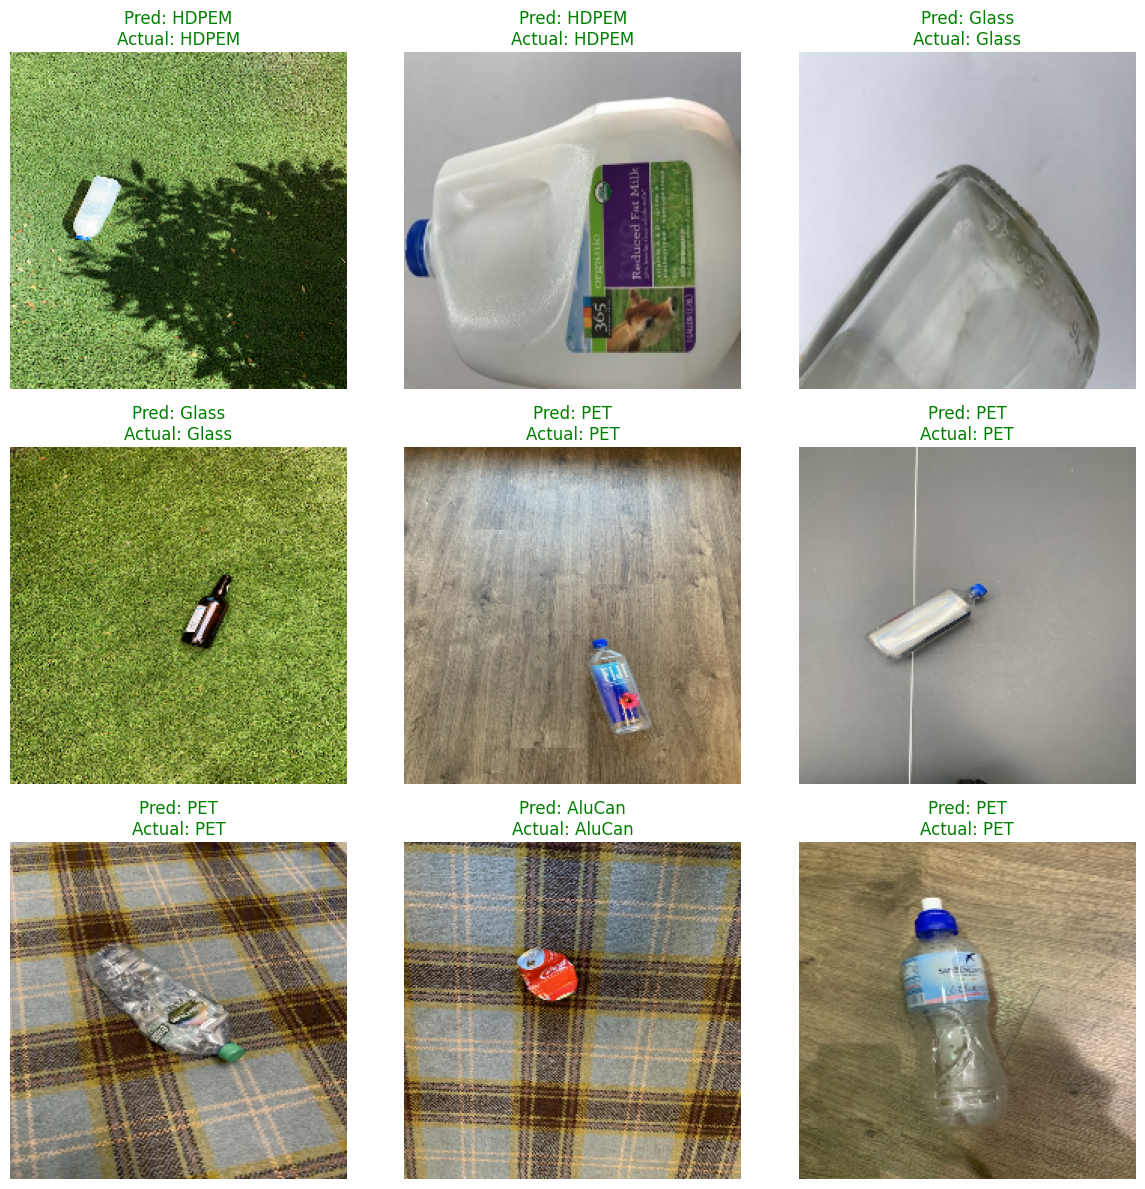

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Get a batch of images and labels from the validation set
# We use the raw_val_ds so we can see the original colors (not the [-1, 1] scaled ones)
image_batch, label_batch = next(iter(raw_val_ds))

# 2. Preprocess the images specifically for the model's prediction
# We apply the same scaling we used during training
processed_images = preprocess_input(image_batch)
predictions = model.predict(processed_images)

# 3. Plot the results
plt.figure(figsize=(12, 12))
for i in range(9):  # Show the first 9 images
    ax = plt.subplot(3, 3, i + 1)

    # Show the image
    plt.imshow(image_batch[i].numpy().astype("uint8"))

    # Get the predicted and actual labels
    predict_index = np.argmax(predictions[i])
    actual_index = np.argmax(label_batch[i])

    predict_name = class_names[predict_index]
    actual_name = class_names[actual_index]

    # Set title color: Green if correct, Red if wrong
    title_color = "green" if predict_name == actual_name else "red"

    plt.title(f"Pred: {predict_name}\nActual: {actual_name}", color=title_color)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
from google.colab import drive
drive.mount('/content/drive')

model.save('/content/drive/MyDrive/waste_classifier_v1.keras')
print("Model saved to Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to Drive!
